### Regression Problem

In [315]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1.1 Data Preparation**

In [316]:
raw_data = pd.read_csv("../Datasets/data.csv")
df = raw_data.copy()

**First Look of data**

In [317]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [318]:
# columns name
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [319]:
# convert into lowercase and fill space with "_"
df.columns = df.columns.str.lower().str.replace(" ","_")

In [320]:
df.head(2)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650


In [321]:
# check datatypes
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [322]:
# convert all the values of string columns into lowercase and fill spaces with '_'
strings = list(df.dtypes[df.dtypes == "str"].index)
for col in strings:
     df[col] = df[col].str.lower().str.replace(" ","_")

In [323]:
df.head(3)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350


**1.2 Exploratory data analysis**

In [324]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print("unique :",df[col].nunique())
    print("_"*40)

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
unique : 48
________________________________________
model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
unique : 914
________________________________________
year
[2011 2012 2013 1992 1993]
unique : 28
________________________________________
engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
unique : 10
________________________________________
engine_hp
[335. 300. 230. 320. 172.]
unique : 356
________________________________________
engine_cylinders
[ 6.  4.  5.  8. 12.]
unique : 9
________________________________________
transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
unique : 5
______________

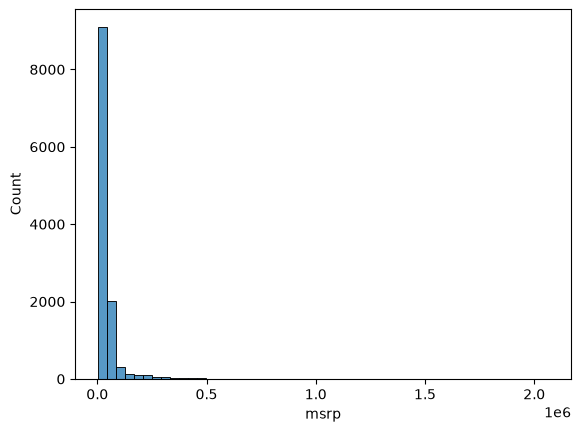

In [325]:
# Distribution of price
sns.histplot(df.msrp, bins=50);

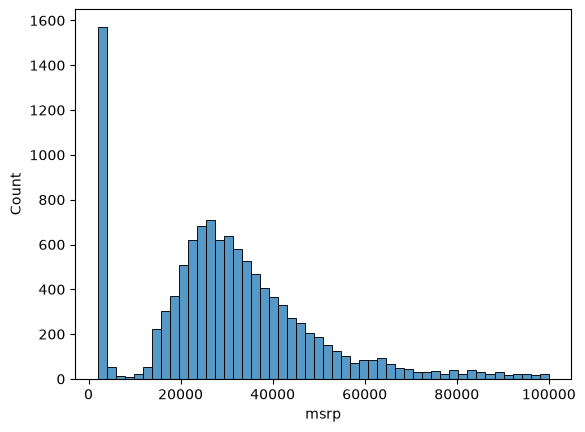

In [326]:
sns.histplot(df.msrp[df.msrp <100000], bins=50);

- distrubtion of the msrp are long tail.

In [327]:
# logrithm transformation
# np.log([0+1,1+1,10+1,100+1,10000+1])
np.log1p([0,1,10,100,10000])

array([0.        , 0.69314718, 2.39789527, 4.61512052, 9.21044037])

In [328]:
# transform price column
price_log = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

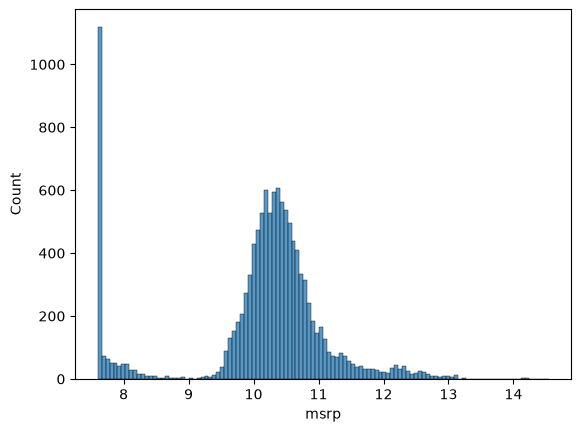

In [329]:
sns.histplot(price_log)

In [330]:
# Missing values
df.isna().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

**1.3 Setting up the validation framework**

```text
┌──────────────────────┬──────────────────┬──────────────────┐
│       DATASET        │                  │                  │
├──────────────────────┼──────────────────┼──────────────────┤
│ 🟦 Training — 60%    │ 🟩 Validation    │ 🟥 Test — 20%    │
│                      │       — 20%      │                  │
├──────────────────────┼──────────────────┼──────────────────┤
│    Learn patterns    │    Tune model    │  Final evaluation│
└──────────────────────┴──────────────────┴──────────────────┘
```



In [331]:
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

n , n_val , n_test , n_train


(11914, 2382, 2382, 7150)

In [332]:
# shuffle the data
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

In [333]:
# Split the dataset into training, validation, and test sets
# to train the model, tune it, and evaluate it on unseen data.
df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [334]:
# reset the index
df_train = df_train.reset_index(drop=True).copy()
df_test = df_test.reset_index(drop=True).copy()
df_val = df_val.reset_index(drop=True).copy()

In [335]:
df_train.shape , df_test.shape, df_val.shape

((7150, 16), (2382, 16), (2382, 16))

In [336]:
# transform our targert features
y_train = np.log1p(df_train.msrp)
y_test = np.log1p(df_test.msrp)
y_val = np.log1p(df_val.msrp)

In [337]:
# drop `'msrp'` from the data
df_train = df_train.drop(['msrp'],axis=1)
df_test = df_test.drop(['msrp'],axis=1)
df_val = df_val.drop(['msrp'],axis=1)

**1.4 Linear regression**

$$
\hat{y}^{(i)} =
w_0 + \sum_{j=1}^{n} w_j x_j^{(i)}
$$

In [338]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [339]:
xi = [453, 11, 86]          # feature values
w0 = 7.17                   # bias (intercept)
w = [0.01, 0.04, 0.002]     # weights

In [340]:
# Linear regression on single example
def Linearregression(xi):
    m = len(xi)
    pred = w0
    for i in range(m):
        pred += w[i]*xi[i]
    return pred
        

In [341]:
Linearregression(xi)

12.312

In [342]:
# How linear regression calculates the output:
# bias + (weight × feature) for each feature
y = 7.17 + 0.01 * 453 + 0.04 * 11 + 0.002 * 86
y

12.312

In [343]:
predication = np.expm1(12.312)
predication

np.float64(222347.2221101062)

In [344]:
np.log1p(222347.2221101062)

np.float64(12.312)

**How Features Affect the Prediction**
* w₀ → Base value before using the inputs.
* weight × input → Contribution of that feature.
* Positive weight + larger input → increases the prediction.
* Negative weight + larger input → decreases the prediction.
* The larger the weight's absolute value, the stronger its effect per unit.

**1.5 Linear regression vector form (multiple example)**

In [345]:
X = np.array([
    [1,148, 24, 1385],
    [1, 132, 24, 2031],
    [1, 453, 11, 86]
    ])
X


array([[   1,  148,   24, 1385],
       [   1,  132,   24, 2031],
       [   1,  453,   11,   86]])

In [346]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [347]:
def linear_regression(X):
    return X.dot(w_new)

In [348]:
linear_regression(X)

array([12.38 , 13.512, 12.312])

**1.6 Training Linear regression(using normal equation)**

$$
w =
\begin{bmatrix}
w_0 \\
w_1 \\
\vdots \\
w_n
\end{bmatrix}
$$

$$
\hat{y} = Xw
$$

$$
w = (X^T X)^{-1}X^T y
$$

In [349]:
X =np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
])
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [350]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [351]:
def train_linear_regression(X,y):
    m =len(X)
    ones = np.ones(m)
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0] , w_full[1:]

In [352]:
w0, w = train_linear_regression(X,y)

**1.7 Baseline model**

In [353]:
# lets build model on numerical features first
base = ["engine_hp","engine_cylinders","highway_mpg","city_mpg","popularity"]
df_train[base].head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657


In [354]:
# for simplification let's fill null values with zero
X_train = df_train[base].fillna(0).values

In [355]:
w0, w = train_linear_regression(X_train,y_train)

In [356]:
w0 , w

(np.float64(7.927257388070037),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [357]:
# predication on training data
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

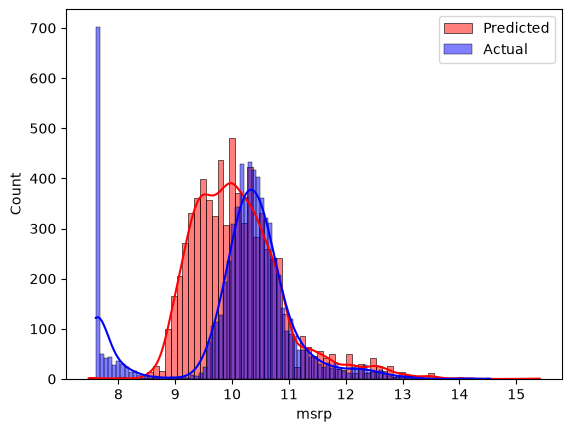

In [358]:
# Visualize and compare the distributions of actual and predicted values
sns.histplot(y_pred, kde=True, label="Predicted", color ="red")
sns.histplot(y_train, kde=True, label="Actual", color="blue")
plt.legend()
plt.show()

**Observation:** The predictions capture the general distribution, but there is still a noticeable gap from the actual values. We can measure this prediction error using **RMSE**. A lower RMSE indicates better predictions. Adding more relevant features may help improve the model.


**1.8 RMSE**
* tells us how far our predictions are from the actual values, on average.
$$
RMSE = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}
$$


In [359]:
def RMSE(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [360]:
RMSE(y_train , y_pred)

np.float64(0.7554192603920132)

The model has an RMSE of 0.75, meaning its predictions are typically about 0.75 units away from the actual values.

**1.9 Validating our model**

In [361]:
def prepare_X(df):
    X = df[base].fillna(0).values
    return X

In [362]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
RMSE(y_val, y_pred)

np.float64(0.7616530991301627)

**Why Validation**
* We use the validation set to check whether the model generalizes to unseen data.
* If the model performs well on training data but poorly on validation data, it may be overfitting.
* So, validation helps us compare different models and choose the one that generalizes better.

**1.10 Simple feature engineering**

In [363]:
def prepare_X(df):
    df = df.copy()
    df["age"] = 2017 - df.year
    features = base + ["age"]
    
    X = df[features].fillna(0).values
    return X

In [364]:
X_train =prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
RMSE(y_val, y_pred)

np.float64(0.5172055461058327)

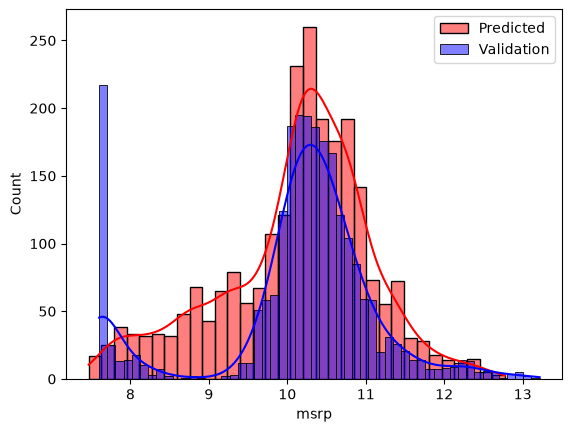

In [365]:
sns.histplot(y_pred, kde=True, label="Predicted", color ="red")
sns.histplot(y_val, kde=True, label="Validation", color="blue")
plt.legend()
plt.show()

**1.11 Categorical Variables**

In [366]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [367]:
def prepare_X(df):
    df = df.copy()
    
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [368]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
RMSE(y_val, y_pred)

np.float64(113.57670443864478)

**Regularization**

In [369]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.0000001],
]

X = np.array(X)
X

array([[4.       , 4.       , 4.       ],
       [3.       , 5.       , 5.       ],
       [5.       , 1.       , 1.       ],
       [5.       , 4.       , 4.       ],
       [7.       , 5.       , 5.       ],
       [4.       , 5.       , 5.0000001]])

In [370]:
y= [1, 2, 3, 1, 2, 3]

In [371]:
XTX = X.T.dot(X)
XTX

array([[140.       , 111.       , 111.0000004],
       [111.       , 108.       , 108.0000005],
       [111.0000004, 108.0000005, 108.000001 ]])

In [372]:
XTX_inv = np.linalg.inv(XTX)

In [373]:
XTX_inv.dot(X.T).dot(y)

array([ 3.25115862e-01, -4.41093100e+06,  4.41093113e+06])

In [374]:
XTX = [
    [1.01,2,2],
    [2,1.01,1],
    [2,1,1.01]
]
XTX = np.array(XTX)

In [375]:
np.linalg.inv(XTX)

array([[ -0.33668906,   0.33501399,   0.33501399],
       [  0.33501399,  49.91540897, -50.08459103],
       [  0.33501399, -50.08459103,  49.91540897]])

In [376]:
XTX = XTX + 0.01 *np.eye(3)
np.linalg.inv(XTX)    

array([[ -0.34009024,   0.33672301,   0.33672301],
       [  0.33672301,  24.91413563, -25.08586437],
       [  0.33672301, -25.08586437,  24.91413563]])

In [381]:
def train_linear_regression_reg(X,y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(X.shape[1]) 
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0] , w_full[1:]

In [382]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
RMSE(y_val, y_pred)

np.float64(0.4608208286405144)